# Toy model: one spin, four sites, a hybrid walk with per-site memory

`toy_single_spin_relaxation` had one site, so the only thing to sample was
the spin's offset from its table value. Here there are four sites, and the
sampler alternates two kinds of move:

- a **discrete** move, which puts the spin on a different site;
- a **continuous** move, which changes one component of the offset
  $(\delta_\parallel, \delta_\perp)$ from the table value of the site the
  spin is on.

**Each site has its own rectangle.** The allowed offsets are ±10% of that
site's table value in each component, so a strongly coupled site is allowed
a wider range in kHz than a weakly coupled one. The prior is flat inside the
rectangle.

**Each site remembers its own offset.** An offset belongs to a site, not to
the spin. When the spin leaves a site, that site's offset stays where the
local walk left it; when the spin comes back, the local walk resumes from
there. A site that has never been visited starts at its table value.

This is the package's **site memory**, switched on by building the state
with `site_memory=True`. Without it, the package's default, the offset
belongs to the spin and travels with it across a hop.

The data are simulated from a spin on site 0 at (105, 52) kHz, which is
site 0's table value of (100, 50) plus an offset of (+5, +2). Two lattices
are run: one where the four rectangles are far apart in coupling space, and
one where they overlap.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RWMH,
    AnalyticCCE1,
    DiscreteLatticeWalk,
    Envelope,
    Experiment,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    NeighborIndex,
    ParameterBlock,
    Schedule,
    SiteScaledOffset,
    SiteTable,
    State,
    Step,
    Target,
    Trace,
    gyromagnetic_ratio,
    simulate_coherence,
    simulate_dataset,
)

# One colour per site, the same in every figure.  The start, the target and
# the recovered value are drawn in ink with distinct marker shapes, so they
# are never confused with a site.
SITE_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
C_RECOVERED = "#4a3aa7"
C_INK, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_AXIS, "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. The sampler

No decoherence envelope, as in the one-site notebook: the forward model is
given an envelope that is one everywhere.

The experiment is CPMG-4. With 16 pulses the dips in the signal are narrow
and the likelihood is a sharp spike at the right coupling. That is fine when
only one site can explain the data, but when two can, a spin that has
relaxed on one of them never crosses to the other: the other site is still
at its table value, which fits far worse. Four pulses give broader dips and
a landscape the walk can cross.

Both moves are the package's own `RWMH`:

- over the `sites` block, with a `DiscreteLatticeWalk`. Because the state
  has site memory, a hop gives the spin the offset the destination site
  remembers, and the hop is accepted or rejected on the likelihood at that
  remembered value.
- over the `offsets` block, with a `SiteScaledOffset` proposal, which walks
  the offset inside the current site's rectangle. Each update is written to
  the site's memory as well as to the spin.

Read as a sampler over all four offsets at once, both moves are ordinary
Metropolis-Hastings steps with symmetric proposals: a hop changes only which
offset the likelihood reads, and an offset step changes only the one in use.

In [2]:
FRACTION = 0.10                        # each rectangle is ±10% of the table value
TRUE_SITE, TRUE_OFFSET = 0, (5.0, 2.0)
DATA_NOISE, LIK_SIGMA = 0.002, 0.02
N_PULSES, B_Z = 4, 311.0
tau = np.linspace(3.2e-5, 8e-3, 250)   # ms
blank = ExperimentSet([Experiment(tau=tau, n_pulses=N_PULSES, b_z=B_Z)])

# Real-space positions only decide which sites are neighbours.  The four sit
# on a 2 Angstrom square and the walk radius reaches all of them, so the spin
# can hop from any site to any other.
POSITIONS = np.array([[0.0, 0.0, 2.0], [2.0, 0.0, 2.0],
                      [0.0, 2.0, 2.0], [2.0, 2.0, 2.0]])
HOP_RADIUS = 5.0


class NoEnvelope(Envelope):
    """No attenuation: the coherence is the spin modulation alone."""

    def __call__(self, tau, exp_id, lam, n_stretch):
        return np.ones_like(np.asarray(tau, dtype=float))


model = AnalyticCCE1(NoEnvelope())

## 2. One run

The schedule is the package's hybrid driver: one site move, then five offset
moves, repeated.

In [3]:
N_STEPS, N_BURN = 12000, 2000
SITE_STEPS, OFFSET_STEPS = 1, 5
STEP_KHZ = 1.0


def run_walk(centres, start_site, seed):
    """Simulate data on ``centres`` and run the hybrid walk from ``start_site``.

    ``centres`` is the (A_par, A_perp) table value of each of the four sites.
    Returns the walk in arrays that include the starting point at index 0.
    """
    centres = np.asarray(centres, dtype=float)
    table = SiteTable(
        distance=np.linalg.norm(POSITIONS, axis=1), positions=POSITIONS,
        a_par=centres[:, 0], a_perp=centres[:, 1],
        isotope=np.array(["13C"] * 4),
        gyro=np.full(4, gyromagnetic_ratio("13C")))

    def make_state(site, d_par=0.0, d_perp=0.0):
        state = State.from_sites(
            (site,), n_sites=4, n_exp=1,
            # A State must carry a decay constant; NoEnvelope never reads it.
            lam=np.ones((1, 1)), n_stretch=np.ones((1, 1)),
            sigma=np.full((1, 1), LIK_SIGMA), k_max=1, site_memory=True)
        state.set_offset(0, 0, 0, d_par)
        state.set_offset(0, 0, 1, d_perp)
        return state

    truth = make_state(TRUE_SITE, *TRUE_OFFSET)
    data = simulate_dataset(truth, blank, table, model, sigma=DATA_NOISE,
                            rng=np.random.default_rng(3))
    target = Target(data, model, GaussianL2(), table)

    schedule = Schedule([
        Step(RWMH(ParameterBlock("sites"),
                  DiscreteLatticeWalk(NeighborIndex(POSITIONS, HOP_RADIUS))),
             SITE_STEPS),
        Step(RWMH(ParameterBlock("offsets"), SiteScaledOffset(
            STEP_KHZ, table, fraction_par=FRACTION, fraction_perp=FRACTION,
            prior="flat")), OFFSET_STEPS),
    ])
    initial = make_state(start_site)
    trace = Trace(n_sites=4, k_max=1, n_exp=1)
    HybridDriver(schedule).run(initial, target, np.random.default_rng(seed),
                               N_STEPS, trace=trace)

    # The trace records the state after each step; put the start at the front.
    site = np.concatenate([[start_site], trace.site_idx[:, 0]])
    d_par = np.concatenate([[0.0], trace.dA_par[:, 0]])
    d_perp = np.concatenate([[0.0], trace.dA_perp[:, 0]])
    log_like = np.concatenate([target.log_prob(initial),
                               np.asarray(trace.log_prob)])

    best = N_BURN + int(np.argmax(log_like[N_BURN:]))
    recovered = make_state(site[best], d_par[best], d_perp[best])
    return {
        "centres": centres, "half": FRACTION * np.abs(centres),
        "start_site": start_site,
        "site": site, "d_par": d_par, "d_perp": d_perp,
        "a_par": centres[site, 0] + d_par, "a_perp": centres[site, 1] + d_perp,
        "log_like": log_like, "best": best,
        "true_coupling": centres[TRUE_SITE] + np.array(TRUE_OFFSET),
        "measured": data.data_all,
        "signal_initial": simulate_coherence(initial, blank, table, model),
        "signal_recovered": simulate_coherence(recovered, blank, table, model),
    }


def report(res):
    site, best, c, half = res["site"], res["best"], res["centres"], res["half"]
    print("allowed couplings, ±10% of each table value:")
    for i in range(4):
        print(f"  site {i}: A_par {c[i, 0] - half[i, 0]:6.1f} – "
              f"{c[i, 0] + half[i, 0]:6.1f}   A_perp "
              f"{c[i, 1] - half[i, 1]:5.1f} – {c[i, 1] + half[i, 1]:5.1f} kHz")
    hops = np.flatnonzero(np.diff(site) != 0)
    kept = site[N_BURN:]
    print(f"site hops: {hops.size} in {N_STEPS} steps "
          f"({(hops >= N_BURN).sum()} after burn-in)")
    print("share of steps after burn-in, by site: "
          + ", ".join(f"site {i}: {np.mean(kept == i):.0%}" for i in range(4)))
    t = res["true_coupling"]
    print(f"target   : site {TRUE_SITE} at ({t[0]:.2f}, {t[1]:.2f}) kHz")
    print(f"recovered: site {site[best]} at ({res['a_par'][best]:.2f}, "
          f"{res['a_perp'][best]:.2f}) kHz, offset "
          f"({res['d_par'][best]:+.2f}, {res['d_perp'][best]:+.2f}), "
          f"log-likelihood {res['log_like'][best]:.2f}")

## 3. Figures

Three views of the same walk, and one of the signals.

- **Coupling space.** Each site's rectangle of allowed couplings, the samples
  coloured by the site the spin was on, and a line for each of the first
  hops.
- **Across sites.** Which site the spin is on at each step, with the misfit
  underneath: the opening steps on the left, the whole run on the right.
- **Within sites.** One panel per site, in that site's own offset
  coordinates.

In [4]:
MAX_HOP_LINES = 25


def _markers(ax, res, offset_of=None):
    """Start, target and recovered value, in absolute or per-site coordinates."""
    c, best = res["centres"], res["best"]
    start = c[res["start_site"]]
    rec = np.array([res["a_par"][best], res["a_perp"][best]])
    shift = np.zeros(2) if offset_of is None else c[offset_of]
    for point, marker, size, face, name in [
        (start, "o", 70, C_INK, "start"),
        (res["true_coupling"], "*", 230, C_INK, "target"),
        (rec, "D", 190, "none", "recovered"),
    ]:
        if offset_of is not None:
            half = res["half"][offset_of]
            if np.any(np.abs(point - shift) > half):
                continue
        ax.scatter([point[0] - shift[0]], [point[1] - shift[1]], s=size,
                   marker=marker, facecolor=face,
                   edgecolor=C_RECOVERED if name == "recovered" else "white",
                   linewidths=2.2 if name == "recovered" else 1.2, zorder=6,
                   label=f"{name} ({point[0]:.1f}, {point[1]:.1f})")


def plot_coupling_space(res, title):
    c, half, site = res["centres"], res["half"], res["site"]
    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    for i in range(4):
        corner = (c[i, 0] - half[i, 0], c[i, 1] - half[i, 1])
        ax.add_patch(Rectangle(corner, 2 * half[i, 0], 2 * half[i, 1],
                               facecolor=SITE_COLOURS[i], alpha=0.10, zorder=0))
        ax.add_patch(Rectangle(corner, 2 * half[i, 0], 2 * half[i, 1],
                               facecolor="none", edgecolor=SITE_COLOURS[i],
                               lw=1.6, zorder=1))
        ax.scatter([c[i, 0]], [c[i, 1]], marker="+", s=60,
                   color=SITE_COLOURS[i], zorder=2)
        on = site == i
        ax.scatter(res["a_par"][on], res["a_perp"][on], s=5,
                   color=SITE_COLOURS[i], alpha=0.35, linewidths=0, zorder=3)
        # A separate, larger handle: the sample dots are too small to read
        # in a legend.
        ax.scatter([], [], s=45, marker="s", color=SITE_COLOURS[i],
                   label=f"site {i}, table ({c[i, 0]:.0f}, {c[i, 1]:.0f})")
    hops = np.flatnonzero(np.diff(site) != 0)
    shown = hops[:MAX_HOP_LINES]
    label = (f"site hop ({hops.size})" if hops.size <= MAX_HOP_LINES
             else f"site hop (first {MAX_HOP_LINES} of {hops.size})")
    for n, h in enumerate(shown):
        ax.plot(res["a_par"][h: h + 2], res["a_perp"][h: h + 2], color=C_INK,
                lw=0.7, alpha=0.5, zorder=4, label=label if n == 0 else None)
    _markers(ax, res)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$A_\parallel$ (kHz)")
    ax.set_ylabel(r"$A_\perp$ (kHz)")
    ax.set_title(title, loc="left", color=C_INK)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_across_sites(res, opening=60):
    """Site and misfit against step: the opening steps, then the whole run.

    The first hops happen within a few steps of the start, where they would be
    a single pixel on the scale of the whole run.
    """
    site, steps = res["site"], np.arange(len(res["site"]))
    fig, axes = plt.subplots(
        2, 2, figsize=(11.5, 5.0), sharex="col", sharey="row",
        gridspec_kw={"width_ratios": [1, 2.6], "hspace": 0.12, "wspace": 0.05})
    for column, last in enumerate((opening, len(steps) - 1)):
        top, bottom = axes[0, column], axes[1, column]
        show = steps <= last
        for ax in (top, bottom):
            ax.axvspan(0, min(N_BURN, last), color="#f0efec", zorder=0)
            ax.set_xlim(0, last)
        for i in range(4):
            on = (site == i) & show
            top.scatter(steps[on], site[on], marker="|", s=120, linewidths=0.8,
                        color=SITE_COLOURS[i], zorder=2)
        if column == 0:
            top.plot(steps[show], site[show], color=C_INK, lw=0.6, zorder=1)
        bottom.plot(steps[show], -res["log_like"][show], color=C_INK, lw=0.8,
                    zorder=2)
        bottom.set_yscale("log")
        bottom.grid(axis="y")
        bottom.set_xlabel("step")
        top.set_title(f"first {opening} steps" if column == 0 else
                      f"whole run, burn-in shaded ({N_BURN} steps)",
                      loc="left", color="#52514e", fontsize=10)
    axes[0, 0].set_yticks(range(4), [f"site {i}" for i in range(4)])
    axes[0, 0].set_ylim(-0.6, 3.6)
    axes[1, 0].set_ylabel("− log-likelihood")
    fig.suptitle("Across sites: where the spin is, step by step", x=0.01,
                 ha="left", color=C_INK)
    plt.show()


def plot_within_sites(res):
    site, half = res["site"], res["half"]
    kept = np.arange(len(site)) >= N_BURN
    fig, axes = plt.subplots(1, 4, figsize=(13.0, 2.9), sharex=True,
                             sharey=True, layout="constrained")
    for i, ax in enumerate(axes):
        ax.add_patch(Rectangle((-half[i, 0], -half[i, 1]), 2 * half[i, 0],
                               2 * half[i, 1], facecolor=SITE_COLOURS[i],
                               alpha=0.10, zorder=0))
        ax.add_patch(Rectangle((-half[i, 0], -half[i, 1]), 2 * half[i, 0],
                               2 * half[i, 1], facecolor="none",
                               edgecolor=SITE_COLOURS[i], lw=1.0, zorder=1))
        early, late = (site == i) & ~kept, (site == i) & kept
        ax.scatter(res["d_par"][early], res["d_perp"][early], s=5,
                   color=C_MUTED, alpha=0.5, linewidths=0, zorder=2)
        ax.scatter(res["d_par"][late], res["d_perp"][late], s=5,
                   color=SITE_COLOURS[i], alpha=0.35, linewidths=0, zorder=3)
        ax.axhline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        ax.axvline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        _markers(ax, res, offset_of=i)
        ax.set_xlim(-half[:, 0].max() * 1.08, half[:, 0].max() * 1.08)
        ax.set_ylim(-half[:, 1].max() * 1.15, half[:, 1].max() * 1.15)
        ax.set_aspect("equal")
        ax.set_title(f"site {i}: {np.mean(site[N_BURN:] == i):.0%} of kept steps",
                     loc="left", color=C_INK, fontsize=10)
        ax.set_xlabel(r"$\delta_\parallel$ (kHz)")
    axes[0].set_ylabel(r"$\delta_\perp$ (kHz)")
    fig.suptitle("Within sites: the offset from each site's table value "
                 "(grey: during burn-in)", x=0.01, ha="left", color=C_INK)
    plt.show()


def plot_signals(res):
    tau_us, measured = tau * 1e3, res["measured"]
    c, best = res["centres"], res["best"]
    start = c[res["start_site"]]
    _, (top, bottom) = plt.subplots(
        2, 1, figsize=(10.5, 6.2), sharex=True,
        gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
    top.scatter(tau_us, measured, s=9, color=C_MUTED, linewidths=0, zorder=2,
                label=f"data: site {TRUE_SITE}, "
                      f"({res['true_coupling'][0]:.0f}, "
                      f"{res['true_coupling'][1]:.0f}) kHz")
    top.plot(tau_us, res["signal_initial"], color=C_INK, lw=1.2, ls="--",
             zorder=1, label=f"start: site {res['start_site']}, "
                             f"({start[0]:.0f}, {start[1]:.0f}) kHz")
    top.plot(tau_us, res["signal_recovered"], color=C_RECOVERED, lw=1.6,
             zorder=3, label=f"recovered: site {res['site'][best]}, "
                             f"({res['a_par'][best]:.1f}, "
                             f"{res['a_perp'][best]:.1f}) kHz")
    top.set_ylabel("coherence")
    top.set_title("Coherence: the start, the data, and what was recovered",
                  loc="left", color=C_INK, pad=28)
    top.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=3,
               fontsize=9, borderaxespad=0.2)
    top.grid(axis="y")

    bottom.axhline(0.0, color=C_AXIS, lw=1.0, zorder=1)
    bottom.plot(tau_us, res["signal_initial"] - measured, color=C_INK, lw=1.0,
                ls="--", zorder=2, label="start − data")
    bottom.plot(tau_us, res["signal_recovered"] - measured, color=C_RECOVERED,
                lw=1.2, zorder=3, label="recovered − data")
    bottom.set_xlabel(r"interpulse spacing $\tau$ (µs)")
    bottom.set_ylabel("model − data")
    bottom.legend(loc="upper left", bbox_to_anchor=(0.0, -0.28), ncols=2,
                  fontsize=9, borderaxespad=0.0)
    bottom.grid(axis="y")
    plt.show()

## 4. Rectangles far apart

The four table values are separated by much more than the rectangles are
wide, so only site 0 can reach the target coupling. The walk starts on
site 2, at its table value.

In [5]:
SEPARATED = [(100.0, 50.0), (130.0, 40.0), (70.0, 62.0), (125.0, 70.0)]
apart = run_walk(SEPARATED, start_site=2, seed=1)
report(apart)

allowed couplings, ±10% of each table value:
  site 0: A_par   90.0 –  110.0   A_perp  45.0 –  55.0 kHz
  site 1: A_par  117.0 –  143.0   A_perp  36.0 –  44.0 kHz
  site 2: A_par   63.0 –   77.0   A_perp  55.8 –  68.2 kHz
  site 3: A_par  112.5 –  137.5   A_perp  63.0 –  77.0 kHz
site hops: 2 in 12000 steps (0 after burn-in)
share of steps after burn-in, by site: site 0: 100%, site 1: 0%, site 2: 0%, site 3: 0%
target   : site 0 at (105.00, 52.00) kHz
recovered: site 0 at (105.13, 51.98) kHz, offset (+5.13, +1.98), log-likelihood -1.29


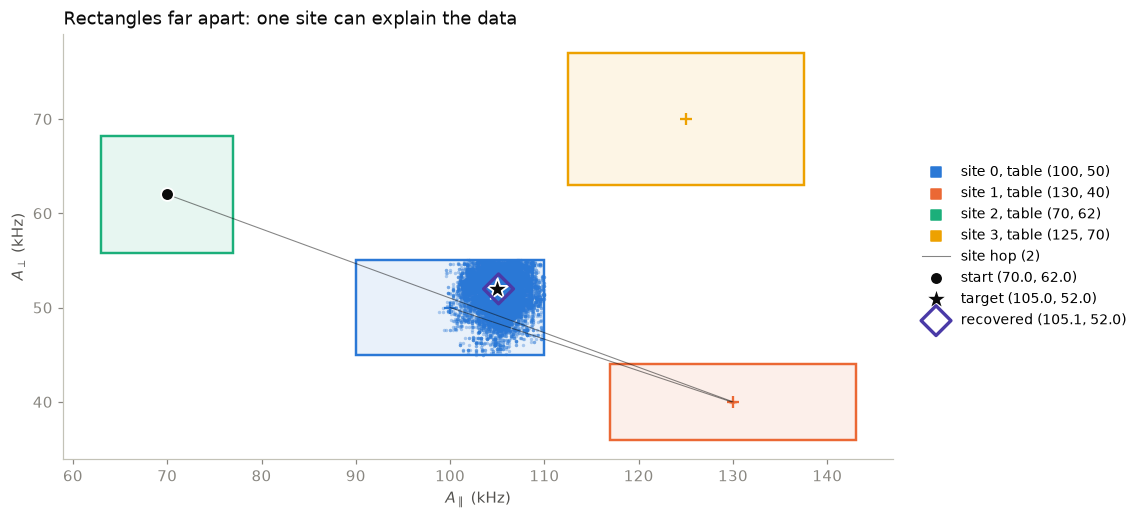

In [6]:
plot_coupling_space(apart, "Rectangles far apart: one site can explain the data")

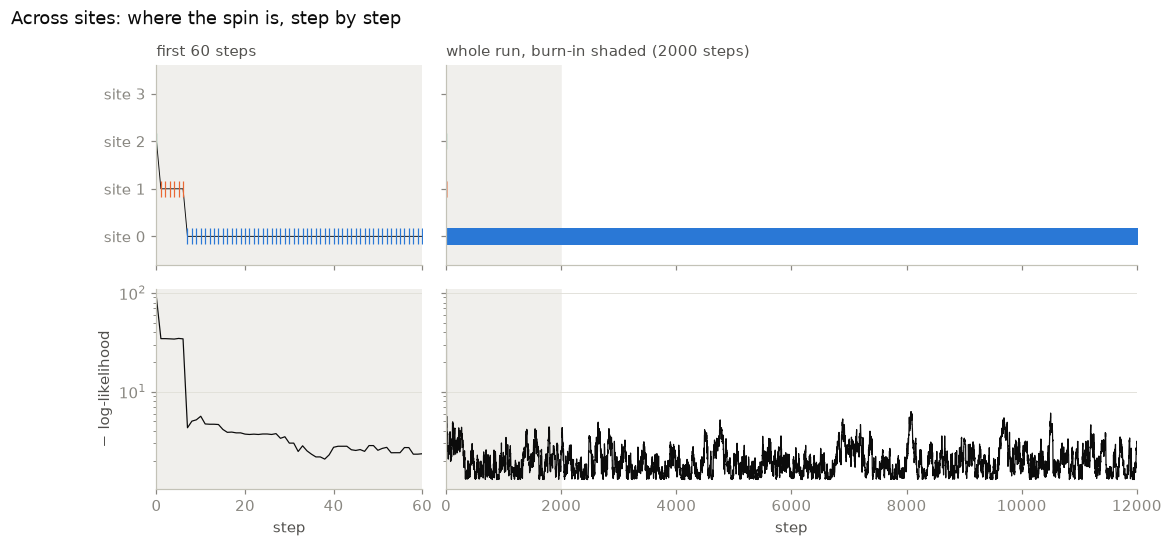

In [7]:
plot_across_sites(apart)

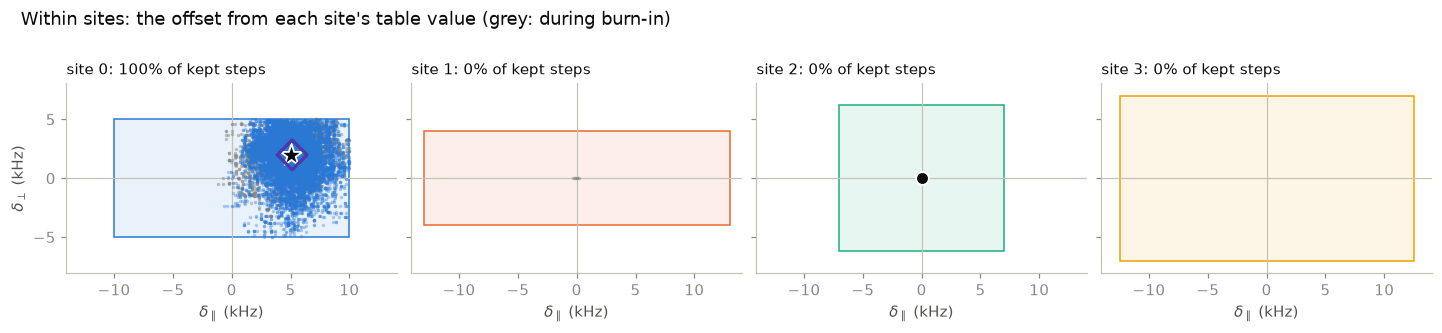

In [8]:
plot_within_sites(apart)

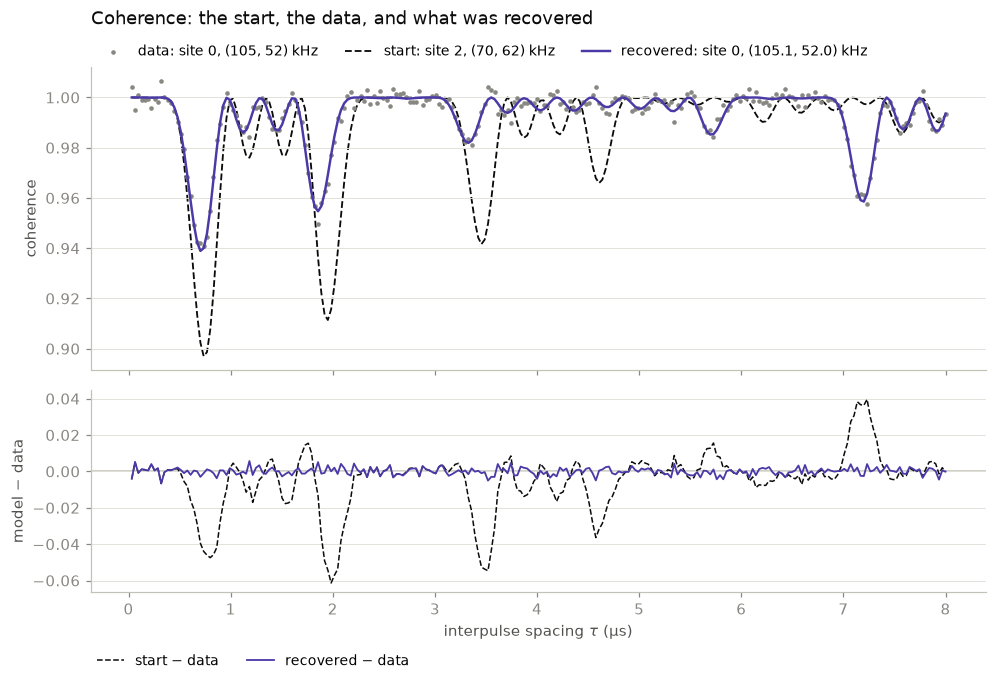

In [9]:
plot_signals(apart)

The spin reaches site 0 in the opening steps and stays there. Once it is on
the only site that can fit the data, every proposed hop is to a site whose
remembered offset fits far worse, and is rejected. After that the run is the
one-site walk of the previous notebook: the across-sites view is flat, and
all of the activity is in one panel of the within-sites view.

A site the spin never visits, or leaves after a few steps, keeps an offset
at or near its table value. Nothing relaxes a site while the spin is
elsewhere.

## 5. Rectangles that overlap

Now the table values lie close enough together that neighbouring rectangles
overlap. The target, (105, 52), is inside two of them: it is site 0 with an
offset of (+5, +2) and equally site 1 with an offset of (−4, −2). The walk
starts on site 3, which cannot reach it.

In [10]:
OVERLAPPING = [(100.0, 50.0), (109.0, 54.0), (88.0, 44.0), (118.0, 60.0)]
overlap = run_walk(OVERLAPPING, start_site=3, seed=0)
report(overlap)

allowed couplings, ±10% of each table value:
  site 0: A_par   90.0 –  110.0   A_perp  45.0 –  55.0 kHz
  site 1: A_par   98.1 –  119.9   A_perp  48.6 –  59.4 kHz
  site 2: A_par   79.2 –   96.8   A_perp  39.6 –  48.4 kHz
  site 3: A_par  106.2 –  129.8   A_perp  54.0 –  66.0 kHz
site hops: 260 in 12000 steps (223 after burn-in)
share of steps after burn-in, by site: site 0: 40%, site 1: 60%, site 2: 0%, site 3: 0%
target   : site 0 at (105.00, 52.00) kHz
recovered: site 1 at (105.13, 52.01) kHz, offset (-3.87, -1.99), log-likelihood -1.29


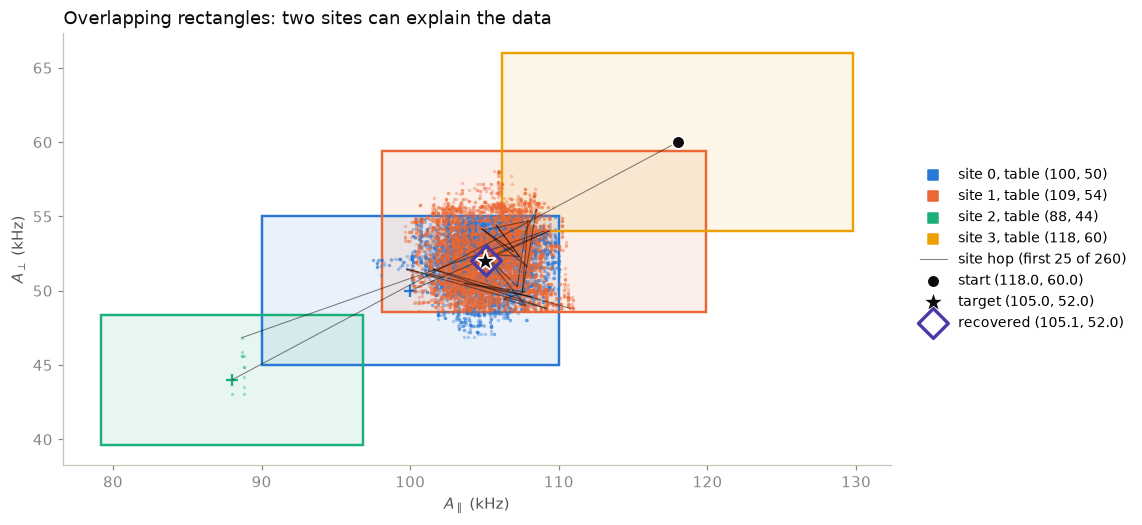

In [11]:
plot_coupling_space(overlap, "Overlapping rectangles: two sites can explain the data")

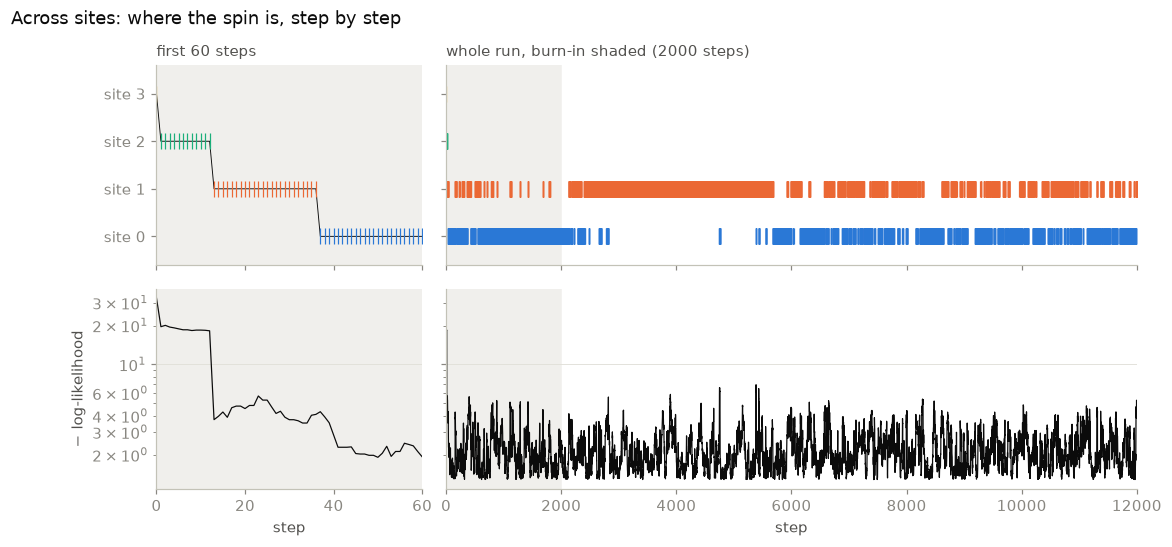

In [12]:
plot_across_sites(overlap)

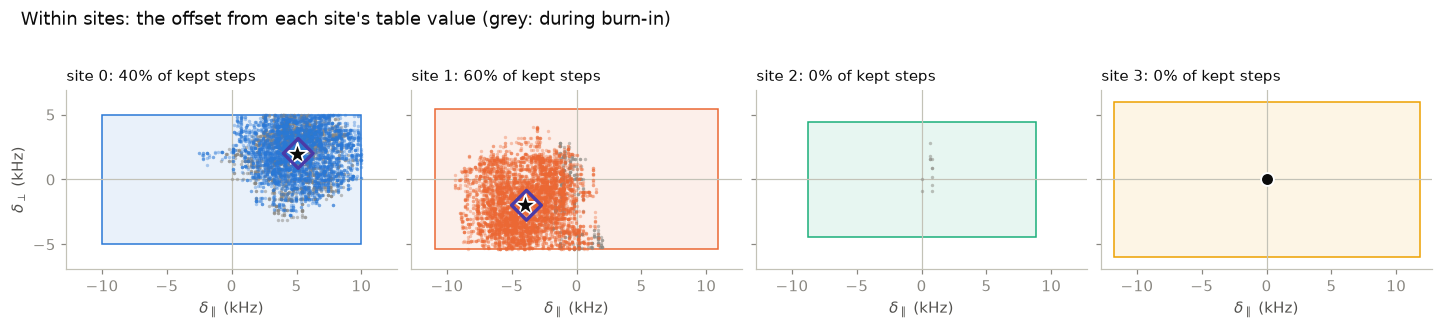

In [13]:
plot_within_sites(overlap)

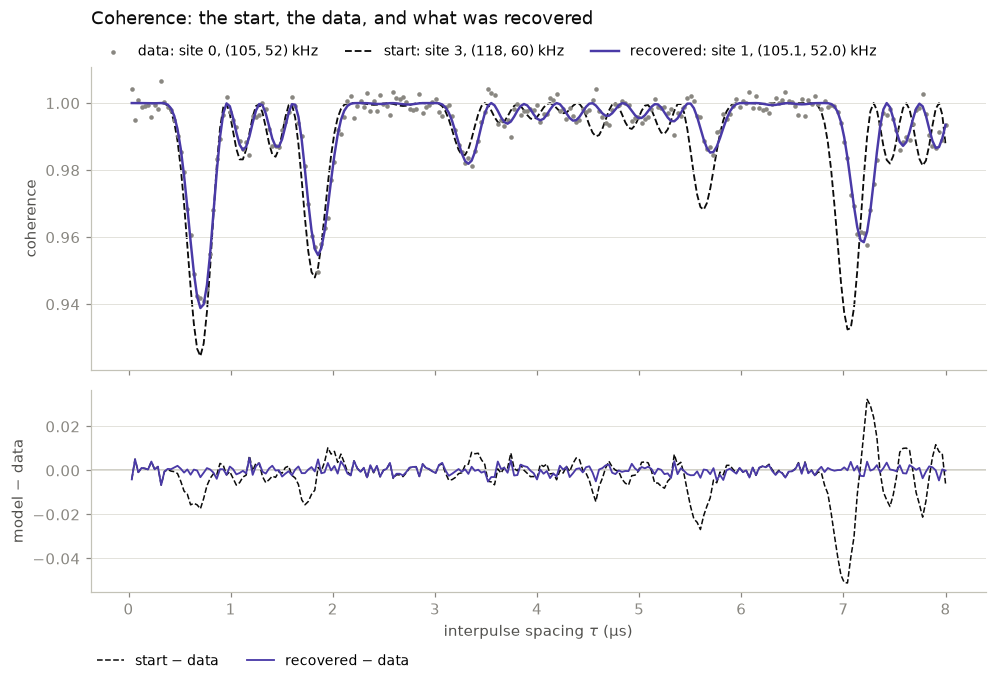

In [14]:
plot_signals(overlap)

The coupling is recovered as before, but the site is not. Both site 0 and
site 1 relax onto the target, each in its own offset coordinates, and from
then on the spin hops between them freely: a hop from one lands on the
other's remembered offset, which is already a good fit, so it is often
accepted. In coupling space the two clouds sit on top of each other.

The data cannot tell the two sites apart. The share of steps on each is
roughly even, 40% to 60% in this run, and across other seeds it stays
between those two figures in either direction. The recovered site is
whichever one the best sample happened to be on; here it is site 1, not the
site the data were simulated from.

This is where the memory matters. Without it, a spin at (+5, +2) on site 0
would land at (+5, +2) on site 1, a coupling of (114, 56) and a poor fit,
and would have to walk to (−4, −2) before the hop could pay off.